# **OpenCV for Computer Vision - Part 2**

In [ ]:
import cv2
import sys
import os
import numpy as np

# 1. Background Subtraction

I once came across a very interesting project on **automatic animal counting** in an animal farm. In many vision-based projects, such as **visitor counting in rooms** or **extracting vehicle information from traffic cameras**, we need to isolate the **object of interest** (animal, visitor, vehicle) by **removing the video background**.

Since the camera is **static**, this task translates to extracting the **moving foreground** from a **stationary background**.

> **Background subtraction** is a fundamental preprocessing step in many vision-based applications.

Useful References:

* [OpenCV Documentation: Background Subtraction](https://docs.opencv.org/3.4/d8/d38/tutorial_bgsegm_bg_subtraction.html)
* [GeeksforGeeks: Python Background Subtraction using OpenCV](https://www.geeksforgeeks.org/python-background-subtraction-using-opencv/)
* [Image](https://www.geeksforgeeks.org/background-subtraction-opencv/)
* [LearnOpenCV: Background Subtraction with OpenCV and BGS Libraries](https://learnopencv.com/background-subtraction-with-opencv-and-bgs-libraries/)

---

### Background Subtraction Pipeline

Background subtraction methods solve the task of foreground extraction by creating a **background model**. The full **Background Subtraction (BS)** pipeline generally involves the following phases:

1. **Background Generation** – Process N frames to create a background image.
2. **Background Modeling** – Define a mathematical model to represent the background.
3. **Background Model Update** – Continuously update the background model to handle changes over time (lighting, scene changes).
4. **Foreground Detection** – Segment pixels into background or foreground classes.

The output of background subtraction is typically a **binary mask**, which separates frame pixels into:

* **Foreground Pixels** (moving objects of interest)
* **Background Pixels** (static regions)

---

### Background Subtraction Algorithms in OpenCV

Several algorithms are available for background subtraction. OpenCV has implemented four popular methods:

1. **BackgroundSubtractorMOG**
   Gaussian Mixture-based Background/Foreground Segmentation algorithm.

2. **BackgroundSubtractorMOG2**
   An enhanced version of MOG that models each background pixel using a mixture of K Gaussian distributions.

3. **BackgroundSubtractorGMG**
   Combines statistical background image estimation with per-pixel Bayesian segmentation.

4. **BackgroundSubtractorKNN**
   Uses K-Nearest Neighbors for Background/Foreground Segmentation.
   Efficient when the number of foreground pixels is low.


In [ ]:
#pip install opencv-contrib-python

In [ ]:
algo = 'MOG2'  # GMG # MOG # KNN # make a choice to see the difference

## ALERT: I could not make GMG work ! Can someone please update the code for GMG working as well?

if algo == 'MOG2':
    backSub = cv2.createBackgroundSubtractorMOG2()
elif algo =='MOG':
    backSub = cv2.createBackgroundSubtractorMOG()
elif algo =='GMG':
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE,(3,3))
    #backSub = cv2.bgsegm.createBackgroundSubtractorGMG()
    backSub = cv2.createBackgroundSubtractorGMG()
else:
    backSub = cv2.createBackgroundSubtractorKNN()

input_video = 'input/trafficCam.mp4'

capture = cv2.VideoCapture(cv2.samples.findFileOrKeep(input_video))

if not capture.isOpened:
    print('Unable to open: ' + input_video)
    exit(0)

while True:
    ret, frame = capture.read()
    if frame is None:
        break
    if algo=='GMG':
        fgmask = backsub.apply(frame)
        fgmask = cv2.morphologyEx(fgmask, cv2.MORPH_OPEN, kernel)
    else:
        fgMask = backSub.apply(frame)

    cv2.rectangle(frame, (10, 2), (100, 20), (255, 255, 255), -1)
    cv2.putText(frame, str(capture.get(cv2.CAP_PROP_POS_FRAMES)), (15, 15),
                       cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 0))

    cv2.imshow('Frame', frame)
    cv2.imshow('FG Mask', fgMask)

    keyboard = cv2.waitKey(30)
    if keyboard == 'q' or keyboard == 27:  # key 27 is the escape key
        break

capture.release()
cv2.destroyAllWindows()

The output shows 2 videos in 2 different windows, original and background removed video. Press Esc to quit.

<h2>2. Object Tracking with Meanshift and Camshift OpenCV</h2>

https://docs.opencv.org/3.4/d7/d00/tutorial_meanshift.html
<br>https://www.geeksforgeeks.org/python-opencv-meanshift/
<br>https://www.tutorialspoint.com/opencv_python/opencv_python_meanshift_camshift.htm

In [ ]:
# mean shift object detection

input_video = 'input/basketball.mp4'
cap = cv2.VideoCapture(input_video)
# take first frame of the video
ret, frame = cap.read()
# setup initial location of window
x, y, w, h = 350, 170, 200, 150  # simply hardcoded the values
track_window = (x, y, w, h)
# set up the ROI for tracking
roi = frame[y:y + h, x:x + w]
hsv_roi = cv2.cvtColor(roi, cv2.COLOR_BGR2HSV)
mask = cv2.inRange(hsv_roi, np.array((0., 60., 32.)), np.array((180., 255., 255.)))
roi_hist = cv2.calcHist([hsv_roi], [0], mask, [180], [0, 180])
cv2.normalize(roi_hist, roi_hist, 0, 255, cv2.NORM_MINMAX)
        # Setup the termination criteria, either 10 iteration or move by atleast 1 pt
term_crit = (cv2.TERM_CRITERIA_EPS | cv2.TERM_CRITERIA_COUNT, 10, 1)

while (1):
    ret, frame = cap.read()
    if ret == True:
        hsv = cv2.cvtColor(frame, cv2.COLOR_BGR2HSV)
        dst = cv2.calcBackProject([hsv], [0], roi_hist, [0, 180], 1)
        # apply meanshift to get the new location
        ret, track_window = cv2.meanShift(dst, track_window, term_crit)
        # Draw it on image
        x, y, w, h = track_window
        img2 = cv2.rectangle(frame, (x, y), (x + w, y + h), 255, 2)
        cv2.imshow('Meanshift', img2)
        k = cv2.waitKey(30) & 0xff
        if k == 27:
            break
    else:
        break
cap.release()
cv2.destroyAllWindows()

You can try with your own video to track an object. Carefully define the initial position of the object and the tracking window size. If you need to lower the video size, you may use this site - https://www.onlineconverter.com/resize-video

### Disadvantages of MeanShift for Object Tracking

There are two main disadvantages when using **MeanShift** for object tracking:

1. **Fixed Window Size**
   The size of the tracking window remains **constant**, regardless of how close or far the object is from the camera. This makes it ineffective when the object scales in size.

2. **Hardcoded Window Initialization**
   The tracking window only works if it starts within the **object's region**. Therefore, we need to **carefully hardcode the initial position** of the window, which is not practical for dynamic or unpredictable scenarios.

https://www.geeksforgeeks.org/track-objects-with-camshift-using-opencv/

In [ ]:
# cam shift
input_video = 'input/slow_traffic_small.mp4'
cap = cv2.VideoCapture(input_video)

# take first frame of the video
ret, frame = cap.read()
# setup initial location of window
x, y, w, h = 300, 200, 100, 50  # simply hardcoded the values
track_window = (x, y, w, h)
# set up the ROI for tracking
roi = frame[y:y + h, x:x + w]
hsv_roi = cv2.cvtColor(roi, cv2.COLOR_BGR2HSV)
mask = cv2.inRange(hsv_roi, np.array((0., 60., 32.)), np.array((180., 255., 255.)))
roi_hist = cv2.calcHist([hsv_roi], [0], mask, [180], [0, 180])
cv2.normalize(roi_hist, roi_hist, 0, 255, cv2.NORM_MINMAX)
# Setup the termination criteria, either 10 iteration or move by atleast 1 pt
term_crit = (cv2.TERM_CRITERIA_EPS | cv2.TERM_CRITERIA_COUNT, 10, 1)

while (1):
    ret, frame = cap.read()
    if ret == True:
        hsv = cv2.cvtColor(frame, cv2.COLOR_BGR2HSV)
        dst = cv2.calcBackProject([hsv], [0], roi_hist, [0, 180], 1)
        # apply camshift to get the new location
        ret, track_window = cv2.CamShift(dst, track_window, term_crit)
        # Draw it on image
        pts = cv2.boxPoints(ret)
        pts = np.int0(pts)
        img2 = cv2.polylines(frame, [pts], True, 255, 2)
        cv2.imshow('Camshift', img2)
        k = cv2.waitKey(30) & 0xff
        if k == 27:
            break
    else:
        break
cap.release()
cv2.destroyAllWindows()

C:\Users\USER\AppData\Local\Temp\ipykernel_33296\3379567189.py:28: DeprecationWarning: `np.int0` is a deprecated alias for `np.intp`.  (Deprecated NumPy 1.24)
  pts = np.int0(pts)


See how the window size changes as the object moves closer to camera.

<h2>3. Optical Flow - Motion Detection -Sparse and Dense</h2>

Optical flow is the pattern of apparent motion of image objects between two consecutive frames caused by the movement of object or camera. The motion detection can be based on only edges of an object (sparse) or all pixels of an object (dense).
<br>https://docs.opencv.org/3.4/d4/dee/tutorial_optical_flow.html
<br>https://docs.opencv.org/4.x/db/d7f/tutorial_js_lucas_kanade.html
<br>https://www.geeksforgeeks.org/python-opencv-optical-flow-with-lucas-kanade-method/

<h3> Sparse Optical flow - Lucas Kanade Method</h3>

In [ ]:
input_video = 'input/slow_traffic_small.mp4'
cap = cv2.VideoCapture(input_video)
# params for ShiTomasi corner detection
feature_params = dict(maxCorners=100,
                        qualityLevel=0.3,
                        minDistance=7,
                        blockSize=7)
        # Parameters for lucas kanade optical flow winSize	size of the search window at each pyramid level.
        # winSize	size of the search window at each pyramid level.
        # maxLevel:	0-based maximal pyramid level number; if set to 0, pyramids are not used (single level),
        # if set to 1, two levels are used, and so on; if pyramids are passed to input then algorithm will use as
        # many levels as pyramids have but no more than maxLevel.
        # criteria:	parameter, specifying the termination criteria of the iterative search algorithm
        #(after the specified maximum number of iterations criteria.maxCount or when the search window moves by less than criteria.epsilon.
lk_params = dict(winSize=(15, 15),maxLevel=2,
                criteria=(cv2.TERM_CRITERIA_EPS | cv2.TERM_CRITERIA_COUNT, 10, 0.03))

# Create some random colors to show paths
color = np.random.randint(0, 255, (100, 3))
# Take first frame and find corners in it
ret, old_frame = cap.read()
old_gray = cv2.cvtColor(old_frame, cv2.COLOR_BGR2GRAY)
p0 = cv2.goodFeaturesToTrack(old_gray, mask=None, **feature_params)
# Create a mask image for drawing purposes
mask = np.zeros_like(old_frame)
while (1):
    ret, frame = cap.read()
    frame_gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    # calculate optical flow
    p1, st, err = cv2.calcOpticalFlowPyrLK(old_gray, frame_gray, p0, None, **lk_params)
    # Select good points
    good_new = p1[st == 1]
    good_old = p0[st == 1]
    # draw the tracks
    for i, (new, old) in enumerate(zip(good_new, good_old)):
        a, b = new.ravel()
        c, d = old.ravel()
        mask = cv2.line(mask, (int(a), int(b)), (int(c), int(d)), color[i].tolist(), 2)
        frame = cv2.circle(frame, (int(a), int(b)), 5, color[i].tolist(), -1)
    img = cv2.add(frame, mask)
    cv2.imshow('Sparse motion detection', img)
    k = cv2.waitKey(30) & 0xff
    if k == 27:
        break
            # Now update the previous frame and previous points
    old_gray = frame_gray.copy()
    p0 = good_new.reshape(-1, 1, 2)
cap.release()
cv2.destroyAllWindows()

To track points in a video sequence, we first need to **detect the points to be tracked**. For this, we will use the OpenCV function:
`cv2.goodFeaturesToTrack()`

The workflow is as follows:

1. Capture the **first frame** of the video.
2. Detect **corner points** in the frame using `cv2.goodFeaturesToTrack()`.
3. These detected points will be tracked across subsequent frames using the **Lucas-Kanade Optical Flow Algorithm**, provided by OpenCV as:
   `cv2.calcOpticalFlowPyrLK()`

<h3> Dense Optical Flow - Franeback Method</h3>

https://www.geeksforgeeks.org/python-opencv-dense-optical-flow/

In [ ]:
#input_video = 'input/slow_traffic_small.mp4'
input_video = 'input/trafficCam.mp4'

cap = cv2.VideoCapture(input_video)
ret, frame1 = cap.read()
prvs = cv2.cvtColor(frame1, cv2.COLOR_BGR2GRAY)
hsv = np.zeros_like(frame1)
hsv[..., 1] = 255

while True:
    ret, frame2 = cap.read()
    next = cv2.cvtColor(frame2, cv2.COLOR_BGR2GRAY)

    flow = cv2.calcOpticalFlowFarneback(prvs, next, None, 0.5, 3, 15, 3, 5, 1.2, 0)
    mag, ang = cv2.cartToPolar(flow[..., 0], flow[..., 1])
    hsv[..., 0] = ang * 180 / np.pi / 2
    hsv[..., 2] = cv2.normalize(mag, None, 0, 255, cv2.NORM_MINMAX)
    bgr = cv2.cvtColor(hsv, cv2.COLOR_HSV2BGR)
    cv2.imshow('franeback', bgr)
    k = cv2.waitKey(30) & 0xff
    if k == 27:
        break
    elif k == ord('s'):
        cv2.imwrite('opticalfb.png', frame2)
        cv2.imwrite('opticalhsv.png', bgr)
    prvs = next
cap.release()
cv2.destroyAllWindows()

Parameters of the function `cv2.calcOpticalFlowFarneback`:

* **prev**: First 8-bit single-channel input image.
* **next**: Second input image of the same size and type as `prev`.
* **flow**: Computed flow image; has the same size as `prev` and type `CV_32FC2`.
* **pyr\_scale**: Image scale (<1) to build pyramids for each image.
  Example: `pyr_scale = 0.5` means each next pyramid layer is half the size of the previous.
* **levels**: Number of pyramid layers including the original image.
  Example: `levels = 1` uses only the original images.
* **winsize**: Averaging window size.
  Larger values increase robustness to image noise and better detect fast motion but may blur the motion field.
* **iterations**: Number of iterations the algorithm performs at each pyramid level.
* **poly\_n**: Size of the pixel neighborhood used for polynomial expansion at each pixel.
  Larger values smooth the motion field but can blur fine motion. Typical values: `poly_n = 5` or `7`.
* **poly\_sigma**: Standard deviation of the Gaussian filter applied to derivatives in the polynomial expansion.
  Example: For `poly_n = 5`, set `poly_sigma = 1.1`; for `poly_n = 7`, use `poly_sigma = 1.5`.
* **flags**: Operation flags. Can be a combination of the following:

  * `cv2.OPTFLOW_USE_INITIAL_FLOW`: Uses the input flow as an initial approximation.
  * `cv2.OPTFLOW_FARNEBACK_GAUSSIAN`: Uses a Gaussian filter of size `winsize × winsize` instead of a box filter.
    This often results in more accurate flow estimation, at the cost of slower computation.
    Typically, `winsize` should be increased when using the Gaussian window to maintain robustness.




You can also check the modification Gunar-Franeback optical flow here.
<br>https://www.geeksforgeeks.org/opencv-the-gunnar-farneback-optical-flow/

<h2>4. HDR Imaging</h2>

High-Dynamic-Range Imaging (**HDRI** or **HDR**) is a technique used in imaging and photography to reproduce a greater **dynamic range of luminosity** than is possible with standard digital imaging or photographic techniques.

While the **human eye** can adapt to a wide range of lighting conditions, most imaging devices are limited to **8-bits per channel** (i.e., 256 levels of intensity). Therefore, when photographing real-world scenes:

* **Bright regions** may get **overexposed** (details lost in brightness)
* **Dark regions** may get **underexposed** (details lost in shadows)
* A **single exposure** cannot capture both simultaneously.

HDR imaging works with images that use **more than 8 bits per channel** (usually **32-bit float values**), allowing a much wider dynamic range.

---

HDR images combine information from **multiple photos taken at different exposures**.
In scenes with **uneven lighting**, a single shot may:

* Overexpose certain areas (too bright, details lost)
* Underexpose darker areas (too dark, details lost)

---

There are various methods to create HDR images, but the **most common** involves capturing **multiple photographs with varying exposure values**.
To properly combine these exposures:

1. It is useful to estimate your camera’s **response function** (algorithms exist to do this).
2. After merging, the HDR image must be **converted back to 8-bit** to display on normal screens.
3. This conversion process is known as **Tone Mapping**.

> Additional complexities arise if objects or the camera **move between shots**. In such cases, images need to be properly **registered and aligned** to avoid artifacts and "ghosting."

---

### Steps to Create an HDR Image:

1. **Capture multiple images** of the scene with different **exposure levels**.

   * Minimum **2**, typically **3** exposures.
   * More images = better quality, but higher **CPU usage**.

2. **Align the images**.

   * Even if a tripod is used, **pixel-level alignment** is necessary.
   * Misalignment leads to visual artifacts or "ghosts" in the final HDR image.

3. **Merge the aligned images** into a single HDR image.

   * Combines information from dark and bright regions.

4. **Perform Tone Mapping**.

   * The real world doesn’t have a maximum brightness of 255.
   * Tone Mapping scales the HDR image back to **0-255 range** for display.
   * This step ensures that high dynamic range details are preserved visually.

---

**References**:

* [A Simple HDR Implementation on OpenCV Python (Medium Article)](https://medium.com/towards-data-science/a-simple-hdr-implementation-on-opencv-python-2325dbd9c650)
* [OpenCV HDR Tutorial (Python)](https://docs.opencv.org/3.4/d2/df0/tutorial_py_hdr.html)
* [OpenCV HDR Imaging Documentation](https://docs.opencv.org/4.x/d3/db7/tutorial_hdr_imaging.html)

In [ ]:
import cv2
import numpy as np

# source: https://github.com/abhishek305/Opencv-HDR-demo

def readImagesAndTimes():

  times = np.array([ 1/30.0, 0.25, 2.5, 15.0 ], dtype=np.float32)

  filenames = ["input/hdr/img_0.033.jpg", "input/hdr/img_0.25.jpg", "input/hdr/img_2.5.jpg", "input/hdr/img_15.jpg"]

  images = []
  for filename in filenames:
    im = cv2.imread(filename)
    images.append(im)

  return images, times

if __name__ == '__main__':
  # Read images and exposure times
  print("Reading images ... ")

  images, times = readImagesAndTimes()


  # Align input images
  print("Aligning images ... ")
  alignMTB = cv2.createAlignMTB()
  alignMTB.process(images, images)

    # It is necessary to know camera response function (CRF) for a lot of HDR construction algorithms.
    # We use one of the calibration algorithms to estimate inverse CRF for all 256 pixel values.
    # We use Debevec's weighting scheme to construct HDR image using response calculated in the previous item.

    # Obtain Camera Response Function (CRF)
  print("Calculating Camera Response Function (CRF) ... ")
  calibrateDebevec = cv2.createCalibrateDebevec()
  responseDebevec = calibrateDebevec.process(images, times)

  # Merge images into an HDR linear image
  print("Merging images into one HDR image ... ")
  mergeDebevec = cv2.createMergeDebevec()
  hdrDebevec = mergeDebevec.process(images, times, responseDebevec)
  # Save HDR image.
  cv2.imwrite("output/hdr/hdrDebevec.hdr", hdrDebevec)
  print("saved hdrDebevec.hdr ")

  # # Tonemap using Drago's method to obtain 24-bit color image
  print("Tonemaping using Drago's method ... ")
  tonemapDrago = cv2.createTonemapDrago(1.0, 0.7)
  ldrDrago = tonemapDrago.process(hdrDebevec)
  ldrDrago = 3 * ldrDrago
  cv2.imwrite("output/hdr/ldr-Drago.jpg", ldrDrago * 255)
  print("saved ldr-Drago.jpg")


  # # Tonemap using Reinhard's method to obtain 24-bit color image
  print("Tonemaping using Reinhard's method ... ")
  tonemapReinhard = cv2.createTonemapReinhard(1.5, 0,0,0)
  ldrReinhard = tonemapReinhard.process(hdrDebevec)
  cv2.imwrite("output/hdr/ldr-Reinhard.jpg", ldrReinhard * 255)
  print("saved ldr-Reinhard.jpg")

  # # Tonemap using Mantiuk's method to obtain 24-bit color image
  print("Tonemaping using Mantiuk's method ... ")
  tonemapMantiuk = cv2.createTonemapMantiuk(2.2,0.85, 1.2)
  ldrMantiuk = tonemapMantiuk.process(hdrDebevec)
  ldrMantiuk = 3 * ldrMantiuk
  cv2.imwrite("output/hdr/ldr-Mantiuk.jpg", ldrMantiuk * 255)
  print("saved ldr-Mantiuk.jpg")


Reading images ... 
Aligning images ... 
Calculating Camera Response Function (CRF) ... 
Merging images into one HDR image ... 
saved hdrDebevec.hdr 
Tonemaping using Drago's method ... 
saved ldr-Drago.jpg
Tonemaping using Reinhard's method ... 
saved ldr-Reinhard.jpg
Tonemaping using Mantiuk's method ... 
saved ldr-Mantiuk.jpg


You can view the HDR image here https://viewer.openhdr.org/
<br>You can check the differences among the 3 different tonemapping methods.

Another example :

In [ ]:
def loadExposureSeq(path):
    images = []
    times = []
    with open('input/hdr_input2/filelist.txt') as f:
        content = f.readlines()
        #print(content)
    for line in content:
        tokens = line.split()
        images.append(cv2.imread(os.path.join('input/hdr_input2/', tokens[0])))
        times.append(1 / float(tokens[1]))
        print(tokens[0], times)
    return images, np.asarray(times, dtype=np.float32)

In [ ]:
    #load input images and exposure times from user-defined folder. The folder should contain images and filelist.txt
    # file that contains file names and inverse exposure times.
    images, times = loadExposureSeq('input/hdr_input2')

    calibrate = cv2.createCalibrateDebevec()
    response = calibrate.process(images, times)
    merge_debevec = cv2.createMergeDebevec()
    hdr = merge_debevec.process(images, times, response)

    # Since we want to see our results on common LDR display we have to map our HDR image to 8-bit range preserving most details.
    # It is the main goal of tonemapping methods. We use tonemapper with bilateral filtering and set 2.2 as the value for gamma correction.
    tonemap = cv2.createTonemap(2.2)
    ldr = tonemap.process(hdr)

    merge_mertens = cv2.createMergeMertens()
    fusion = merge_mertens.process(images)

    cv2.imwrite('output/hdr2/fusion.png', fusion * 255)
    cv2.imwrite('output/hdr2/ldr.png', ldr * 255)
    cv2.imwrite('output/hdr2/hdr.hdr', hdr)


memorial00.png [32.0]
memorial01.png [32.0, 16.0]
memorial02.png [32.0, 16.0, 8.0]
memorial03.png [32.0, 16.0, 8.0, 4.0]
memorial04.png [32.0, 16.0, 8.0, 4.0, 2.0]
memorial05.png [32.0, 16.0, 8.0, 4.0, 2.0, 1.0]
memorial06.png [32.0, 16.0, 8.0, 4.0, 2.0, 1.0, 0.5]
memorial07.png [32.0, 16.0, 8.0, 4.0, 2.0, 1.0, 0.5, 0.25]
memorial08.png [32.0, 16.0, 8.0, 4.0, 2.0, 1.0, 0.5, 0.25, 0.125]
memorial09.png [32.0, 16.0, 8.0, 4.0, 2.0, 1.0, 0.5, 0.25, 0.125, 0.0625]
memorial10.png [32.0, 16.0, 8.0, 4.0, 2.0, 1.0, 0.5, 0.25, 0.125, 0.0625, 0.03125]
memorial11.png [32.0, 16.0, 8.0, 4.0, 2.0, 1.0, 0.5, 0.25, 0.125, 0.0625, 0.03125, 0.015625]
memorial12.png [32.0, 16.0, 8.0, 4.0, 2.0, 1.0, 0.5, 0.25, 0.125, 0.0625, 0.03125, 0.015625, 0.0078125]
memorial13.png [32.0, 16.0, 8.0, 4.0, 2.0, 1.0, 0.5, 0.25, 0.125, 0.0625, 0.03125, 0.015625, 0.0078125, 0.00390625]
memorial14.png [32.0, 16.0, 8.0, 4.0, 2.0, 1.0, 0.5, 0.25, 0.125, 0.0625, 0.03125, 0.015625, 0.0078125, 0.00390625, 0.001953125]
memorial15.

True

Check the fusion and ldr image. Check the HDR image https://viewer.openhdr.org/ and also use mouse scroll to check the image at different exposure.

<h2>5. Epipolar Geometry</h2>

We have **two eyes**—like **two cameras**—which help us not only see a scene but also **perceive depth** (how far objects are from us). This ability is known as **Stereo Vision**.

However, when we take a **single photograph**, we lose this depth information because we convert a **3D scene into a 2D image**. But by using **multiple cameras (or images from different angles)**, we can use **OpenCV** to retrieve **depth information** about objects in a scene.

**Epipolar Geometry** is a part of **Multiview Geometry** that deals with the **geometric relationship between two views of the same scene**.

* **Source**: [GeeksforGeeks – Epipolar Geometry with OpenCV](https://www.geeksforgeeks.org/python-opencv-epipolar-geometry/)

You can read more from the link above.
Also, refer to this detailed tutorial:

* [OpenCV Documentation: Epipolar Geometry (Python)](https://docs.opencv.org/4.x/da/de9/tutorial_py_epipolar_geometry.html)

---

### We will perform 2 tasks using Epipolar Geometry:

1. **Match keypoints** of images taken from **two different angles**.
2. **Draw the depth map** of the image.

---

We will use:

* **SIFT (Scale-Invariant Feature Transform)** for **keypoint extraction**
* **Flann-Based Matching** for finding keypoint correspondences between images

Additionally, we will require **two matrices** for the computation:

* **Camera Intrinsic Matrix**
* **Essential or Fundamental Matrix**

In [ ]:
# drawing epilines between 2 images taken from different angles
# more pictures can be found at https://vision.middlebury.edu/stereo/data/scenes2005/
# I downloaded and added in the input folder as ALL-2Views.zip

from matplotlib import pyplot as plt

def drawlines(img1, img2, lines, pts1, pts2):
    r, c = img1.shape
    img1 = cv2.cvtColor(img1, cv2.COLOR_GRAY2BGR) # convert gray image to bgr
    img2 = cv2.cvtColor(img2, cv2.COLOR_GRAY2BGR) # convert gray image to bgr
    for r, pt1, pt2 in zip(lines, pts1, pts2):
        color = tuple(np.random.randint(0, 255, 3).tolist()) # 3 random combination between 0 to 255
        x0, y0 = map(int, [0, -r[2] / r[1]])                 #starting cordinates
        x1, y1 = map(int, [c, -(r[2] + r[0] * c) / r[1]])    # end point cordinates
        img1 = cv2.line(img1, (x0, y0), (x1, y1), color, 1)   # draw lines on the images
        img1 = cv2.circle(img1, tuple(pt1), 5, color, -1)     # draw circle on the images
        img2 = cv2.circle(img2, tuple(pt2), 5, color, -1)     # draw circle on the images
    return img1, img2


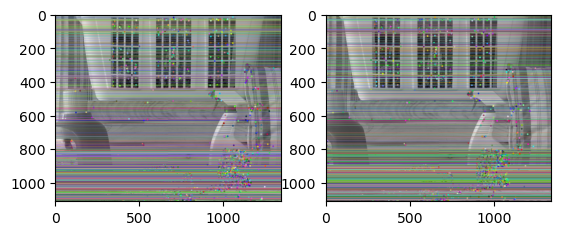

In [ ]:
img1 = cv2.imread("input/view0.png", 0)  # 0 means importing in gray scale
img2 = cv2.imread("input/view2.png", 0)

sift = cv2.SIFT_create()

# find the keypoints and descriptors with SIFT
kp1, des1 = sift.detectAndCompute(img1, None)
kp2, des2 = sift.detectAndCompute(img2, None)
# FLANN parameters
FLANN_INDEX_KDTREE = 1
index_params = dict(algorithm=FLANN_INDEX_KDTREE, trees=5)
search_params = dict(checks=50)
flann = cv2.FlannBasedMatcher(index_params, search_params)
matches = flann.knnMatch(des1, des2, k=2)
pts1 = []
pts2 = []
    # ratio test as per Lowe's paper - It compares the distance between two nearest neighbors for identifying distinctive correspondence
    # The idea is that for a good match the distance between two nearest matches for a certain keypoint is below a threshold, or vice versa.
    # epipolar geometry algorithm is used to find if two images are same.

for i, (m, n) in enumerate(matches):
    if m.distance < 0.8 * n.distance: # checking for the distance between the two images
        pts2.append(kp2[m.trainIdx].pt) # train image - img2 / right image
        pts1.append(kp1[m.queryIdx].pt) # query image - img1 / left image
    #This loop defines which matches will be discarded and which matches will be preserved.
    #So, if m distance is less than 80% of n distance, then the descriptor for that particular row will be preserved.
    #On the other hand, if m distance is greater than 80% of n distance, then it’s probably not a good match, and the descriptor for
    #that particular row will be discarded. Therefore less distance means a better match.

pts1 = np.int32(pts1)
pts2 = np.int32(pts2)
F, mask = cv2.findFundamentalMat(pts1, pts2, cv2.FM_LMEDS)
# We select only inlier points
pts1 = pts1[mask.ravel() == 1]
pts2 = pts2[mask.ravel() == 1]

lines1 = cv2.computeCorrespondEpilines(pts2.reshape(-1, 1, 2), 2, F)
lines1 = lines1.reshape(-1, 3)
img5, img6 = drawlines(img1, img2, lines1, pts1, pts2) # call the function drawlines()
        # Find epilines corresponding to points in left image (first image) and
        # drawing its lines on right image
lines2 = cv2.computeCorrespondEpilines(pts1.reshape(-1, 1, 2), 1, F)
lines2 = lines2.reshape(-1, 3)
img3, img4 = drawlines(img2, img1, lines2, pts2, pts1)
plt.subplot(121), plt.imshow(img5)
plt.subplot(122), plt.imshow(img3)
plt.show()


You can try with more images from the zip file ALL-2Views.zip given inside the input folder

<h3>Depth Map</h3>

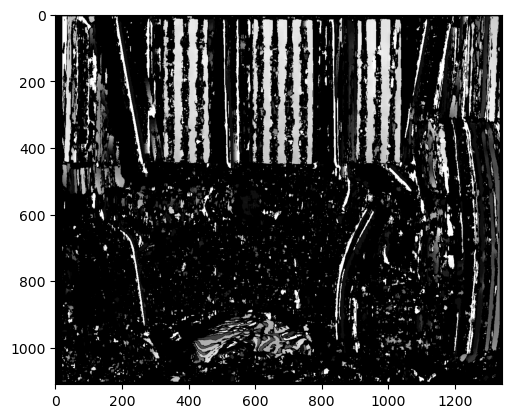

In [ ]:
# reading both of the images in grayscale format
imgL = cv2.imread("input/view0.png", 0)
imgR = cv2.imread("input/view2.png", 0)
"""        numDisparities the disparity search range. For each pixel algorithm will find the best
blockSize the linear size of the blocks compared by the algorithm. The size should be odd        """
stereo = cv2.StereoBM_create(numDisparities=16, blockSize=15)
disparity = stereo.compute(imgL, imgR)
plt.imshow(disparity, 'gray')
plt.show()

Here the darker objects are closer. The further away an object is, the whiter it is. You can find a couple of examples here below.
<br>https://www.geeksforgeeks.org/python-opencv-depth-map-from-stereo-images/
<br>https://docs.opencv.org/4.x/dd/d53/tutorial_py_depthmap.html
<br> Please note that the second example above is more appropriate to understand the concept.

<h2>6. Color Quantization</h2>

Color quantization is the process of reducing colors in an image, either to reduce memory or to use the device that cannot support high range of colors. We use k-means clustering in OpenCV to use this. We will give an initial value of K (colors we want) and a stopping criteria; the image will be recolored to our specified number of colors by clustering.
<br>https://docs.opencv.org/4.x/d1/d5c/tutorial_py_kmeans_opencv.html
<br>https://www.tutorialspoint.com/color-quantization-in-an-image-using-k-means-in-opencv-python

In [ ]:
img = cv2.imread('input/view0.png')

Z = img.reshape((-1, 3))
# convert to np.float32
Z = np.float32(Z)

# define stopping criteria, number of clusters(K) and apply kmeans()
criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 10, 1.0)
K = 2
ret, label, center = cv2.kmeans(Z, K, None, criteria, 10, cv2.KMEANS_RANDOM_CENTERS)
# Now convert back into uint8, and make original image
center = np.uint8(center)
res = center[label.flatten()]
res2 = res.reshape((img.shape))
cv2.imshow('res2', res2)
cv2.imwrite('output/2coloredimage.jpg', res2)
cv2.waitKey(0)
cv2.destroyAllWindows()

You can try with different images and change values of K to experiment.

<h2>7. Non-local Image Denoising</h2>

In **OpenCV**, "**local denoising**" refers to image noise reduction techniques that consider only the **immediate neighborhood** of a pixel to calculate its new value.

In contrast, "**non-local denoising**" (like the **Non-Local Means (NLM) algorithm**) searches for **similar pixel patches across the entire image**, leveraging information from distant areas to remove noise while preserving image details.

* **Local denoising** looks at nearby pixels only.
* **Non-local denoising** searches for similar patterns throughout the image to denoise a pixel.

---

<font color="red"><b>Key Points about the Difference:</b></font>

<b>Local Denoising:</b><br>

* Only considers pixels in a small window around the target pixel.
* Simple to implement but may blur edges and lose details in complex images.
* Examples: Median filter, Gaussian filter.

<b>Non-Local Denoising (NLM):</b><br>

* Searches for similar pixel patches across the entire image to calculate a weighted average for each pixel.
* Better at preserving image details and edges compared to local methods.
* More computationally expensive than local denoising.

---

<b>How NLM Works:</b><br>

* For each pixel, a small window (patch) around it is considered.
* The algorithm searches for **similar patches** elsewhere in the image.
* The pixel value is updated by taking a **weighted average** of pixels from similar patches.

---

<b>Image Denoising</b> is the process of removing noise from an image to make its important features more visible and to increase the efficiency of further data processing tasks.

Useful References:

* [Different Image Denoising Techniques](https://www.geeksforgeeks.org/what-are-the-different-image-denoising-techniques-in-computer-vision/)
* [Non-Local Means Denoising (Python Example)](https://www.bogotobogo.com/python/OpenCV_Python/python_opencv3_Image_Non-local_Means_Denoising_Algorithm_Noise_Reduction.php)
* [OpenCV Docs: Non-Local Means Denoising](https://docs.opencv.org/3.4/d5/d69/tutorial_py_non_local_means.html)
* [Denoising Colored Images using OpenCV](https://www.geeksforgeeks.org/python-denoising-of-colored-images-using-opencv/)
* [Non-Local Means Denoising (MATLAB Demo)](https://amroamroamro.github.io/mexopencv/opencv/non_local_means_demo.html)

---

<b>Recap from Earlier:</b><br>
In earlier chapters, we explored image smoothing techniques like **Gaussian Blurring**, **Median Blurring**, etc., which were effective to some extent in removing small amounts of noise.

In those techniques, we considered a **small neighbourhood (kernel)** around a pixel and applied operations like:

* Gaussian Weighted Average
* Median Value Replacement

In short, noise removal was **local** to a pixel's immediate neighborhood.

---

<b>Important Concept about Noise:</b><br>
Noise is generally considered a **random variable with zero mean**.

Example:
For a noisy pixel, `p = p₀ + n` where

* `p₀` is the true value of the pixel
* `n` is the noise component.

If you take a **large number (N) of the same pixel from multiple images** and compute their average, ideally, you should get back `p = p₀`, since the mean of noise is zero.

---

<b>Non-Local Means Denoising:</b><br>
When multiple similar patches are available **within the same image**, you can:

* Take a pixel and its small window (patch)
* Search for similar windows in the image
* Average these windows and replace the pixel with the result

This is how **Non-Local Means Denoising** works.
It is **computationally more expensive** than simple blurring but provides **superior results** in preserving details.

---

### OpenCV provides four variations of this technique:

1. **cv.fastNlMeansDenoising()** – works with a single grayscale image.
2. **cv.fastNlMeansDenoisingColored()** – works with color images.
3. **cv.fastNlMeansDenoisingMulti()** – works with image sequences captured in a short time (grayscale images).
4. **cv.fastNlMeansDenoisingColoredMulti()** – same as above, but for color images.

---

<b>Common Parameters:</b>

* **h**: Filter strength. Higher `h` removes noise better but may also remove image details. (Typical: 10)
* **hForColorComponents**: Same as `h`, but applied to color components. (Usually same as `h`)
* **templateWindowSize**: Size of the template patch (must be odd). (Recommended: 7)
* **searchWindowSize**: Size of the window to search for similar patches (must be odd). (Recommended: 21)

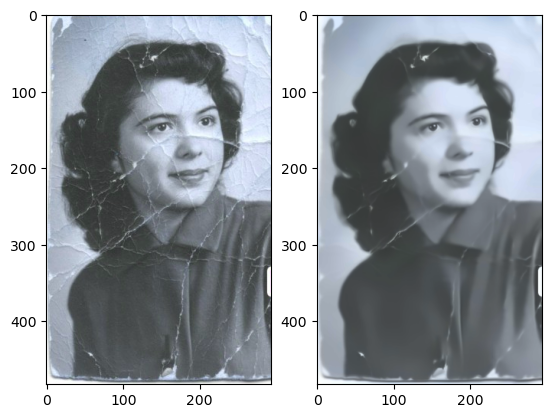

In [ ]:
img = cv2.imread('input/old_photo.png')
# common parameters are discussed above
dst = cv2.fastNlMeansDenoisingColored(img, None, 10, 10, 7, 21)
plt.subplot(121), plt.imshow(img)
plt.subplot(122), plt.imshow(dst)
plt.show()

You can use different methods and parameter values from the above to see which one gives you best results. Often you use multiple techniques of denoising, or a combination of local (Gaussian / Median etc.) and non-local method.

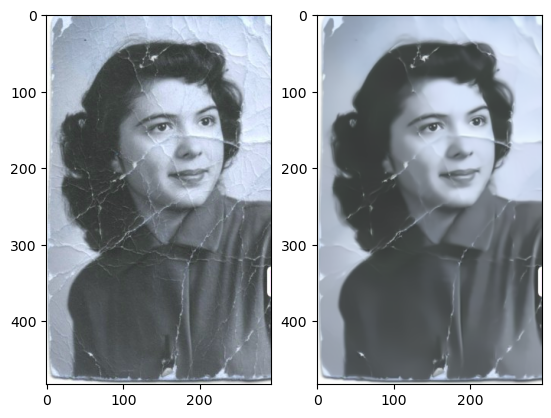

In [ ]:
# This one is for images in Grayscale
img = cv2.imread('input/old_photo.png')

dst = cv2.fastNlMeansDenoising(img, None, 10, 7, 21)
plt.subplot(121), plt.imshow(img)
plt.subplot(122), plt.imshow(dst)
plt.show()

You can see that the first one performed better. Please be careful about using images in grayscale,

There are 2 main types of noise in an image; Salt and pepper noise, Gaussian noise. <b>Let's write some code below to add noise to an image.</b> Then we can practice different denoising techniques. You can find some image archives here to practice. <br>https://ipolcore.ipol.im/demo/clientApp/archive.html?id=55&page=1

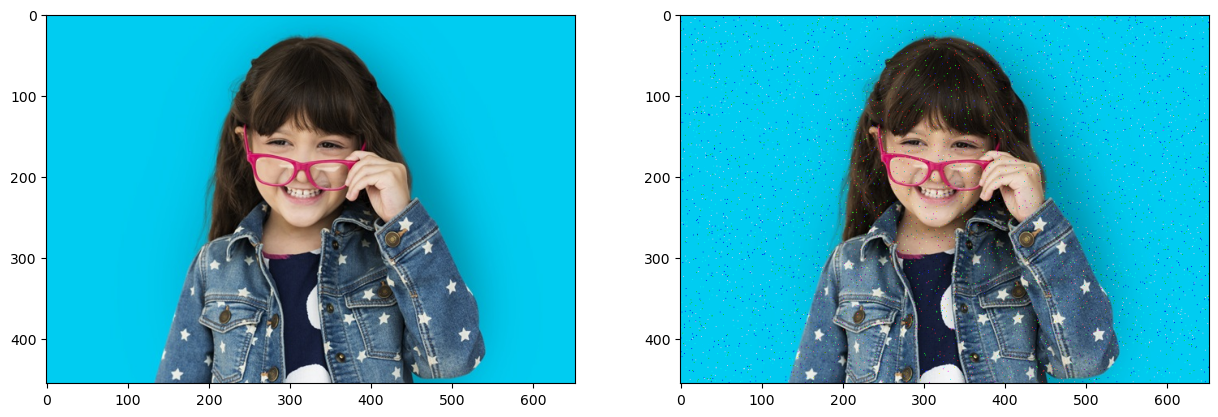

In [ ]:
import numpy as np
import cv2

img_source=cv2.imread('input/little girl.jpg')
img_source = cv2.cvtColor(img_source, cv2.COLOR_BGR2RGB)
img_dest = cv2.imread('input/little girl.jpg')
img_dest = cv2.cvtColor(img_dest, cv2.COLOR_BGR2RGB)

# I tried img_dest = img_source, but it adds noise to both as it only creates a reference. Thus,
# change to destination image also spoils the original image. But it works in MATLAB.

# add some Gaussian noise

def add_gaussian_noise(img_dest, do_noise_gauss):
    if do_noise_gauss:
        m = 0  # noise mean
        sd = 0.4 * np.std(img_dest.astype(np.float64) / 255)  # noise standard deviation

        try:
            # OpenCV has an imnoise equivalent via cv2.randn
            noise = np.random.normal(m, sd, img_dest.shape)
            img_dest = img_dest.astype(np.float64) / 255 + noise
            img_dest = np.clip(img_dest, 0, 1)    # Ensure values are within [0,1]
            img_dest = (img_dest * 255).astype(np.uint8)
        except:
            noise = np.random.randn(*img_dest.shape) * sd + m
            img_dest = img_dest.astype(np.float64) / 255 + noise
            img_dest = np.clip(img_dest, 0, 1)
            img_dest = (img_dest * 255).astype(np.uint8)

    return img_dest

# add some Salt & Pepper noise
def add_salt_and_pepper_noise(img_dest, do_noise_saltnpepper):
    if do_noise_saltnpepper:
        prcnt = 0.01  # noise density
        mask = np.random.rand(*img_dest.shape)
        img_dest[mask < prcnt / 2] = 0
        img_dest[mask > 1 - prcnt / 2] = 255

    return img_dest

# call the 2 functions
add_gaussian_noise(img_dest, True)
add_salt_and_pepper_noise(img_dest, True)

#cv2.imwrite('output/noise_added.jpg', img_dest)
cv2.imwrite('output/noise_added.jpg', cv2.cvtColor(img_dest, cv2.COLOR_RGB2BGR))

# show noisy image
plt.figure(figsize=(15, 15))
plt.subplot(121), plt.imshow(img_source)
plt.subplot(122), plt.imshow(img_dest)
plt.show()

Box Filter              : [PSNR = 24.184934] Elapsed time is 0.000000 seconds.
Gaussian Filter         : [PSNR = 24.361563] Elapsed time is 0.000000 seconds.
Median Filter           : [PSNR = 27.601041] Elapsed time is 0.000000 seconds.
Bilateral Filter        : [PSNR = 35.793054] Elapsed time is 0.018831 seconds.
Non-Local Means Filter  : [PSNR = 28.411865] Elapsed time is 1.306578 seconds.


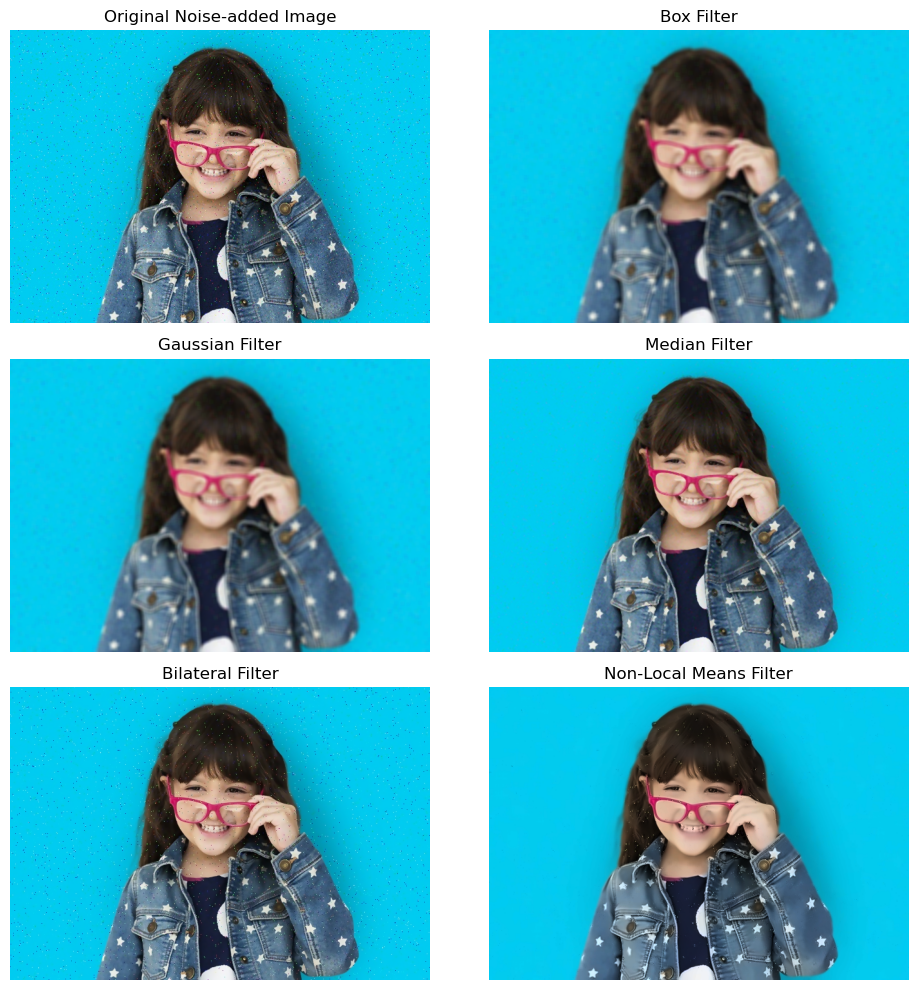

In [ ]:
import time
import matplotlib.pyplot as plt

def apply_filters(dst):
    filters = [
        ("Box Filter", lambda img: cv2.boxFilter(img, -1, (7, 7))),
        ("Gaussian Filter", lambda img: cv2.GaussianBlur(img, (7, 7), 5, 5)),
        ("Median Filter", lambda img: cv2.medianBlur(img, 3)),
        ("Bilateral Filter", lambda img: cv2.bilateralFilter(img, 7, 35, 5)),
        ("Non-Local Means Filter", lambda img: cv2.fastNlMeansDenoising(img, h=9) if len(img.shape) == 2 else cv2.fastNlMeansDenoisingColored(img, h=9, hColor=9))
    ]
    fig, axes = plt.subplots(3, 2, figsize=(10, 10))
    axes = axes.flatten()

     # Show original image in the first subplot
    axes[0].imshow(cv2.cvtColor(dst, cv2.COLOR_BGR2RGB))
    #axes[0].imshow(img_dest)
    axes[0].set_title("Original Noise-added Image")
    axes[0].axis("off")

    for i, (name, filter_func) in enumerate(filters):
        start_time = time.time()
        out = filter_func(dst)
        elapsed_time = time.time() - start_time
        psnr_value = cv2.PSNR(dst, out)

        print(f"{name:23s} : [PSNR = {psnr_value:.6f}] Elapsed time is {elapsed_time:.6f} seconds.")

        #cv2.imshow(name, out)
        axes[i+1].imshow(cv2.cvtColor(out, cv2.COLOR_BGR2RGB))
        axes[i+1].set_title(name)
        axes[i+1].axis("off")
    #cv2.waitKey(0)
    #cv2.destroyAllWindows()
    plt.tight_layout()
    plt.show()


noisyImage=cv2.imread('output/noise_added.jpg')
#img_source = cv2.cvtColor(img_source, cv2.COLOR_BGR2RGB)
apply_filters(noisyImage)

You can see that Non-local Means filter took maximum time to remove the noise we added, and it worked better than Gaussian, Bilateral and Box filter. However, for this case, Median filter performed the best - removing most of the noise and keeping the image quality unchanged.

Note: An image's PSNR value, or "Peak Signal-to-Noise Ratio," is a metric used to quantify the quality of a reconstructed or compressed image compared to its original version, essentially indicating how much distortion is present; a higher PSNR value means the image quality is better with less noticeable distortion, usually measured in decibels (dB).

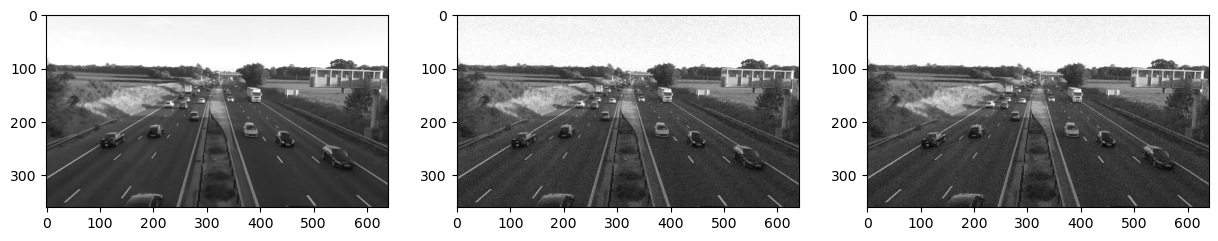

In [ ]:
# denoising a video - first we add some noise, then we denoise it
# If you find a noisy video, you can directly apply denoising

cap = cv2.VideoCapture('input/trafficCam.mp4')
# create a list of first 5 frames
img = [cap.read()[1] for i in range(5)]
# convert all to grayscale
gray = [cv2.cvtColor(i, cv2.COLOR_BGR2GRAY) for i in img]
# convert all to float64
gray = [np.float64(i) for i in gray]
# create a noise of variance 25
noise = np.random.randn(*gray[1].shape) * 10
# Add this noise to images
noisy = [i + noise for i in gray]
# Convert back to uint8
noisy = [np.uint8(np.clip(i, 0, 255)) for i in noisy]
# Denoise 3rd frame considering all the 5 frames
dst = cv2.fastNlMeansDenoisingMulti(noisy, 2, 5, None, 4, 7, 35)

plt.figure(figsize=(15, 15))
plt.subplot(131), plt.imshow(gray[2], 'gray')
plt.subplot(132), plt.imshow(noisy[2], 'gray')
plt.subplot(133), plt.imshow(dst, 'gray')
plt.show()

You can see that the first image is from the original video, the second one is noisy, and the third one is after denoising - removing some noise from the second one (although not as clear as the original one).

<h2>Miscellaneous</h2>

<h4> Motion Detection in Darkness</h4>

In [ ]:
#Source: https://github.com/abhishek305/Motion-Detection-in-dark-using-opencv/blob/master/Night%20detect.py
import cv2

def diffImg(t0, t1, t2):
  d1 = cv2.absdiff(t2, t1)
  d2 = cv2.absdiff(t1, t0)
  return cv2.bitwise_and(d1, d2)

cam = cv2.VideoCapture(0)

winName = "Night Motion Detector"
cv2.namedWindow(winName, cv2.WINDOW_AUTOSIZE)


t1 = cv2.cvtColor(cam.read()[1], cv2.COLOR_RGB2GRAY)
t = cv2.cvtColor(cam.read()[1], cv2.COLOR_RGB2GRAY)
t2 = cv2.cvtColor(cam.read()[1], cv2.COLOR_RGB2GRAY)

while True:
  cv2.imshow( winName, diffImg(t1, t, t2) )


  t1 = t
  t = t2
  t2 = cv2.cvtColor(cam.read()[1], cv2.COLOR_RGB2GRAY)

  key = cv2.waitKey(10)
  if key == 27:
    cv2.destroyWindow(winName)
    break

cam.release()
cv2.destroyAllWindows()

<h4>Stitching Multiple Images into One</h4>

You can stitch multiple pictures or scanned / photocopied images into one using OpneCV's image stitcher. Check out this amazing feature below.

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
# File paths to the images

image_paths=['input/stitch/bridge/s1.jpg','input/stitch/bridge/s2.jpg']
#image_paths = ['input/stitch/newspaper/n1.jpg', 'input/stitch/newspaper/n2.jpg',
#               'input/stitch/newspaper/n3.jpg','input/stitch/newspaper/n4.jpg']

images = []

# Load and resize images to reduce memory usage
max_width = 1000  # Example width to resize images to (adjust as needed)

for path in image_paths:
    image = cv2.imread(path)
    if image is None:
        print(f"Error: Unable to load image {path}")
    else:
        # Resize the image if its width is larger than max_width
        if image.shape[1] > max_width:
            scale_factor = max_width / float(image.shape[1])
            new_dim = (max_width, int(image.shape[0] * scale_factor))
            image = cv2.resize(image, new_dim)
        images.append(image)

# Check if there are enough images to proceed
if len(images) < 2:
    print("Error: Not enough images to stitch.")
else:
    # Initialize the stitcher
    stitcher = cv2.Stitcher_create()

    # Perform stitching
    status, stitched_image = stitcher.stitch(images)

    # Check the status and display the result
    if status == cv2.Stitcher_OK:
        print("Stitching successful.")
        cv2.imshow("Stitched Image", stitched_image)
        cv2.waitKey(0)
        cv2.destroyAllWindows()
    else:
        print(f"Stitching failed with status code {status}")


Stitching successful.


Please check the input images and the output image as stitched.

Stitching successful.


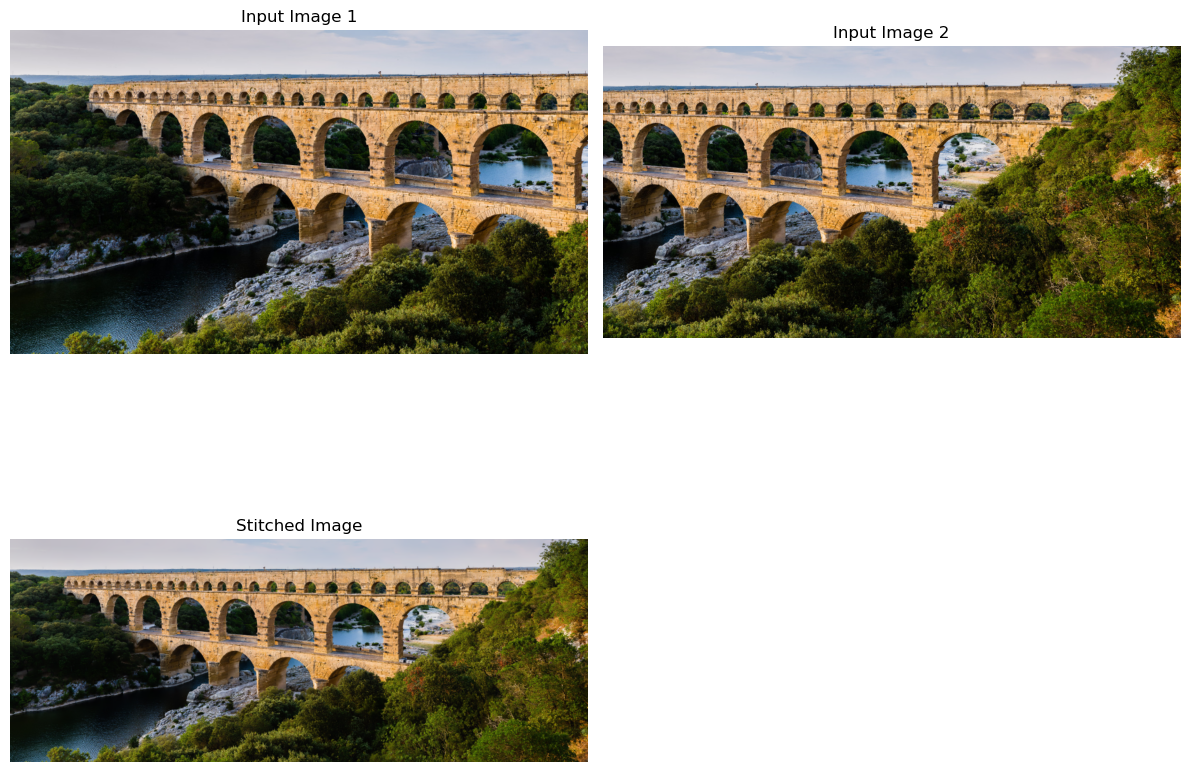

In [ ]:
# here is another version
import cv2
import numpy as np
import matplotlib.pyplot as plt

# File paths to the images
#image_paths = ['input/stitch/newspaper/n1.jpg', 'input/stitch/newspaper/n2.jpg',
#               'input/stitch/newspaper/n3.jpg','input/stitch/newspaper/n4.jpg']

image_paths=['input/stitch/bridge/s1.jpg','input/stitch/bridge/s2.jpg']
images = []

# Load and resize images to reduce memory usage
max_width = 1000  # Example width to resize images to (adjust as needed)

for path in image_paths:
    image = cv2.imread(path)
    if image is None:
        print(f"Error: Unable to load image {path}")
    else:
        # Resize the image if its width is larger than max_width
        if image.shape[1] > max_width:
            scale_factor = max_width / float(image.shape[1])
            new_dim = (max_width, int(image.shape[0] * scale_factor))
            image = cv2.resize(image, new_dim)
        images.append(image)

# Check if there are enough images to proceed
if len(images) < 2:
    print("Error: Not enough images to stitch.")
else:
    # Initialize the stitcher
    stitcher = cv2.Stitcher_create()

    # Perform stitching
    status, stitched_image = stitcher.stitch(images)

    # Check the status and display the result
    if status == cv2.Stitcher_OK:
        print("Stitching successful.")

        # Convert images from BGR (OpenCV format) to RGB (matplotlib format)
        images_rgb = [cv2.cvtColor(img, cv2.COLOR_BGR2RGB) for img in images]
        stitched_rgb = cv2.cvtColor(stitched_image, cv2.COLOR_BGR2RGB)

        # Plot the input images and the stitched image
        plt.figure(figsize=(12, 10))

        # Plot input images in a single row
        for i, img in enumerate(images_rgb):
            plt.subplot(2, len(images_rgb), i + 1)
            plt.imshow(img)
            plt.title(f"Input Image {i + 1}")
            plt.axis('off')

        # Plot the stitched image in a separate row
        plt.subplot(2, len(images_rgb), len(images_rgb) + 1)
        plt.imshow(stitched_rgb)
        plt.title("Stitched Image")
        plt.axis('off')

        plt.tight_layout()  # Adjust spacing
        plt.show()
    else:
        print(f"Stitching failed with status code {status}")


For the newspaper images, please check why the newspaper header is missing. Can you fix it for me?

# ***THE END.***